# Scam Call Detection — EDA, Data Vigilance Checks, Baselines & DistilBERT

**Purpose of this notebook:** validate the full pipeline (data quality → EDA → classical baselines → DistilBERT fine-tuning → stratified evaluation) on the `BothBosu` scam/non-scam dialogue datasets, on Kaggle, before porting anything into the main project repo.

**Datasets used (same phone-dialogue format, avoids the Phase-1 corpus-mismatch bug):**
- `BothBosu/multi-agent-scam-conversation`
- `BothBosu/scam-dialogue`

**Run this on Kaggle with:**
- Internet **ON** (Settings → Internet → On) — needed for `datasets` (Hugging Face) downloads
- GPU accelerator **ON** (T4 x2 or P100) — needed for DistilBERT fine-tuning in reasonable time

**Known bug fixed in this notebook (vs. the earlier script):** tokenization and the stratified length-based evaluation now use the **same** `MAX_LENGTH` value. Previously, training truncated at 256 tokens while the stratified check split at 512 — making that check meaningless, since every input had already been truncated to 256 before the model ever saw it.


## 0. Setup

In [1]:
# Kaggle usually has most of these preinstalled; -q install ensures versions are present
!pip install -q datasets lightgbm scikit-learn seaborn matplotlib evaluate


: 

In [2]:
import os
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    average_precision_score, confusion_matrix, classification_report
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from scipy.stats import mannwhitneyu
import lightgbm as lgb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# *** Single source of truth for truncation length — used by BOTH training and evaluation ***
MAX_LENGTH = 512

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("MAX_LENGTH (tokenization + stratification threshold):", MAX_LENGTH)


Device: cuda
MAX_LENGTH (tokenization + stratification threshold): 512


## 1. Load & Merge Datasets

**Sources combined here, and why each one is included — and what to watch for with each:**
- `BothBosu/multi-agent-scam-conversation` + `BothBosu/scam-dialogue` — phone-dialogue format, good volume, but built from a **closed 4-scam-type x 4-legit-type taxonomy**. Confirmed limitation: vocabulary maps ~1:1 onto `type`, making the task trivially linearly separable on its own.
- `teeconnie/scam-and-non-scam-call-conversation-dataset` (Kaggle, files include `English_Scam.txt`) — real, collected scam reports + ChatGPT-augmented, not built from a fixed category taxonomy. Adds genuine vocabulary diversity.
- `ibrahimbagwan12/composite-scam-transcript-dataset` (Kaggle) — Phase 1's dataset, with a **confirmed register-mismatch artifact** (legit half from an SMS-text corpus, scam half from formal call-transcripts). Included this run per explicit request — the source-predictability check below quantifies the residual risk.
- `narayanyadav/fraud-call-india-dataset` (Kaggle) — **excluded from the training merge by default (`INCLUDE_FRAUD_INDIA_DATASET = False`).** Confirmed via direct inspection: columns are `type`/`clue`, content is short single-utterance SMS-style text (e.g. "Thank you!", "Oh that was a forwarded message."), not phone-call dialogue — the same register mismatch as the original composite dataset's bug, visible before any check even runs. Also severely imbalanced (638 fraud / 5,287 normal, ~10.8% fraud). Set the flag to `True` only if you want the source-predictability check to confirm this numerically rather than take it on inspection alone.


In [3]:
INCLUDE_COMPOSITE_DATASET = True  # merging everything this run, per instruction — checks below will flag residual risk
INCLUDE_FRAUD_INDIA_DATASET = False  # excluded by default — confirmed short SMS-style text, not dialogue; see warning above

ds1 = load_dataset("BothBosu/multi-agent-scam-conversation")
ds2 = load_dataset("BothBosu/scam-dialogue")

def to_df(ds_dict, source_name):
    frames = []
    for split in ds_dict.keys():
        d = ds_dict[split].to_pandas()
        d["source_dataset"] = source_name
        d["source_split"] = split
        frames.append(d)
    return pd.concat(frames, ignore_index=True)

df1 = to_df(ds1, "multi-agent-scam-conversation")
df2 = to_df(ds2, "scam-dialogue")

print("multi-agent-scam-conversation columns:", df1.columns.tolist(), "rows:", len(df1))
print("scam-dialogue columns:", df2.columns.tolist(), "rows:", len(df2))


README.md: 0.00B [00:00, ?B/s]

agent_conversation_train.csv: 0.00B [00:00, ?B/s]

agent_conversation_test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/320 [00:00<?, ? examples/s]

...

scam-dialogue_train.csv: 0.00B [00:00, ?B/s]

scam-dialogue_test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/320 [00:00<?, ? examples/s]

multi-agent-scam-conversation columns: ['dialogue', 'personality', 'type', 'labels', 'source_dataset', 'source_split'] rows: 1600
scam-dialogue columns: ['dialogue', 'type', 'label', 'source_dataset', 'source_split'] rows: 1600


In [4]:
# --- teeconnie/scam-and-non-scam-call-conversation-dataset (Kaggle) ---
import kagglehub

teeconnie_path = kagglehub.dataset_download("teeconnie/scam-and-non-scam-call-conversation-dataset")
print("Downloaded to:", teeconnie_path)

import glob
teeconnie_files = glob.glob(teeconnie_path + "/**/*", recursive=True)
print("Files found:", teeconnie_files)


Downloaded to: /kaggle/input/datasets/teeconnie/scam-and-non-scam-call-conversation-dataset
Files found: ['/kaggle/input/datasets/teeconnie/scam-and-non-scam-call-conversation-dataset/English_Scam.txt', '/kaggle/input/datasets/teeconnie/scam-and-non-scam-call-conversation-dataset/English_NonScam.txt']


In [5]:
# File names vary by dataset version (e.g. "English_Scam.txt" / "scam.txt") — search flexibly and print
# what was matched so you can confirm it picked up the right files.

def load_txt_samples(filepath, label):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()
    entries = [e.strip() for e in content.split("\n\n") if e.strip()]
    if len(entries) < 5:
        entries = [e.strip() for e in content.split("\n") if e.strip()]
    return pd.DataFrame({"text": entries, "label": label})

scam_txt = [f for f in teeconnie_files if f.lower().endswith(".txt") and "non" not in f.lower() and "scam" in f.lower()]
nonscam_txt = [f for f in teeconnie_files if f.lower().endswith(".txt") and "non" in f.lower() and "scam" in f.lower()]
print("Matched as SCAM file(s):", scam_txt)
print("Matched as NON-SCAM file(s):", nonscam_txt)

df3_parts = []
if scam_txt:
    df3_parts.append(load_txt_samples(scam_txt[0], label=1))
if nonscam_txt:
    df3_parts.append(load_txt_samples(nonscam_txt[0], label=0))

if df3_parts:
    df3 = pd.concat(df3_parts, ignore_index=True)
    df3["source_dataset"] = "teeconnie-scam-nonscam"
    df3["source_split"] = "all"
    print("teeconnie rows loaded:", len(df3))
    print(df3["label"].value_counts())
else:
    df3 = pd.DataFrame(columns=["text", "label", "source_dataset", "source_split"])
    print("WARNING: could not auto-match scam/non-scam files — check `teeconnie_files` above and fix the filter manually.")


Matched as SCAM file(s): []
Matched as NON-SCAM file(s): ['/kaggle/input/datasets/teeconnie/scam-and-non-scam-call-conversation-dataset/English_Scam.txt', '/kaggle/input/datasets/teeconnie/scam-and-non-scam-call-conversation-dataset/English_NonScam.txt']
teeconnie rows loaded: 400
label
0    400
Name: count, dtype: int64


In [6]:
# --- ibrahimbagwan12/composite-scam-transcript-dataset (Phase 1 dataset, known register-mismatch artifact) ---

df4 = pd.DataFrame(columns=["text", "label", "source_dataset", "source_split"])

if INCLUDE_COMPOSITE_DATASET:
    composite_path = kagglehub.dataset_download("ibrahimbagwan12/composite-scam-transcript-dataset")
    print("Downloaded to:", composite_path)
    csv_files = glob.glob(composite_path + "/**/*.csv", recursive=True)
    print("CSV files found:", csv_files)
    frames = []
    for f in csv_files:
        d = pd.read_csv(f)
        if "text" in d.columns and "label" in d.columns:
            frames.append(d[["text", "label"]])
    if frames:
        df4 = pd.concat(frames, ignore_index=True)
        df4["source_dataset"] = "composite-scam-transcript"
        df4["source_split"] = "all"
        print("composite dataset rows loaded:", len(df4))


Downloaded to: /kaggle/input/datasets/ibrahimbagwan12/composite-scam-transcript-dataset
CSV files found: ['/kaggle/input/datasets/ibrahimbagwan12/composite-scam-transcript-dataset/composite_test.csv', '/kaggle/input/datasets/ibrahimbagwan12/composite-scam-transcript-dataset/composite_train.csv']
composite dataset rows loaded: 45939


In [7]:
# --- narayanyadav/fraud-call-india-dataset (Kaggle) ---
# CONFIRMED schema (via direct inspection): columns are `type` (fraud/normal) and `clue` (short text).
# CONFIRMED content: short single-utterance SMS-style text, not phone-call dialogue — same register
# mismatch as the original composite dataset's bug. Excluded from the merge by default (see flag above).

df5 = pd.DataFrame(columns=["text", "label", "source_dataset", "source_split"])

if INCLUDE_FRAUD_INDIA_DATASET:
    fraud_india_path = kagglehub.dataset_download("narayanyadav/fraud-call-india-dataset")
    print("Downloaded to:", fraud_india_path)
    fraud_india_files = glob.glob(fraud_india_path + "/**/*.csv", recursive=True)
    print("CSV files found:", fraud_india_files)

    if fraud_india_files:
        d5 = pd.read_csv(fraud_india_files[0])
        d5 = d5.rename(columns={"clue": "text", "type": "label"})
        d5["label"] = d5["label"].astype(str).str.strip().str.lower().map(
            lambda v: 1 if v == "fraud" else 0
        )
        d5["source_dataset"] = "fraud-call-india"
        d5["source_split"] = "all"
        df5 = d5
        print("fraud-call-india rows loaded:", len(df5))
        print(df5["label"].value_counts())
        print("Median word count in this source (compare against the multi-turn dialogue sources' ~250-400):",
              df5["text"].astype(str).str.split().apply(len).median())
else:
    print("INCLUDE_FRAUD_INDIA_DATASET is False — skipping (recommended default; confirmed short SMS-style text, not dialogue).")


INCLUDE_FRAUD_INDIA_DATASET is False — skipping (recommended default; confirmed short SMS-style text, not dialogue).


In [8]:
# Standardize column names across BothBosu sources before merging.
rename_map_1 = {"dialogue": "text", "labels": "label"}
rename_map_2 = {"dialogue": "text", "labels": "label"}

df1 = df1.rename(columns=rename_map_1)
df2 = df2.rename(columns=rename_map_2)

keep_cols = ["text", "label", "type", "source_dataset", "source_split"]
df1 = df1[[c for c in keep_cols if c in df1.columns]]
df2 = df2[[c for c in keep_cols if c in df2.columns]]
df3_aligned = df3.reindex(columns=keep_cols)
df4_aligned = df4.reindex(columns=keep_cols)
df5_aligned = df5.reindex(columns=keep_cols)

df_all = pd.concat([df1, df2, df3_aligned, df4_aligned, df5_aligned], ignore_index=True)
df_all = df_all.dropna(subset=["text", "label"]).reset_index(drop=True)
df_all["label"] = df_all["label"].astype(int)

print("Combined shape:", df_all.shape)
print(df_all["label"].value_counts(normalize=True) * 100)
print()
print("Rows per source dataset:")
print(df_all["source_dataset"].value_counts())
df_all.head(3)


Combined shape: (49539, 5)
label
1    55.636973
0    44.363027
Name: proportion, dtype: float64

Rows per source dataset:
source_dataset
composite-scam-transcript        45939
multi-agent-scam-conversation     1600
scam-dialogue                     1600
teeconnie-scam-nonscam             400
Name: count, dtype: int64


,text,label,type,source_dataset,source_split
0,"Innocent: Hello. Suspect: Hi, this is Karen f...",0,appointment,multi-agent-scam-conversation,train
1,"Innocent: Hello. Suspect: Hi, this is Karen f...",0,appointment,multi-agent-scam-conversation,train
2,"Innocent: Hello. Suspect: Hi, this is Karen f...",0,appointment,multi-agent-scam-conversation,train


In [9]:
# Stratified train/test split (by label AND source_dataset so both sources are represented in both splits)
df_all["strata"] = df_all["label"].astype(str) + "_" + df_all["source_dataset"]

train_df, test_df = train_test_split(
    df_all, test_size=0.2, random_state=SEED, stratify=df_all["strata"]
)
train_df = train_df.drop(columns=["strata"]).reset_index(drop=True)
test_df = test_df.drop(columns=["strata"]).reset_index(drop=True)

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=True) * 100)

os.makedirs("/kaggle/working/data", exist_ok=True)
train_df.to_csv("/kaggle/working/data/train.csv", index=False)
test_df.to_csv("/kaggle/working/data/test.csv", index=False)


Train: 39631 rows | Test: 9908 rows

Train label distribution:
label
1    55.63574
0    44.36426
Name: proportion, dtype: float64


## 2. Data Quality & Leakage Vigilance Checks

**Do this before trusting any downstream result.** With four sources merged, the most important new question is: *can a model tell which source dataset a row came from, and does that leak into predicting the label?* Section 2.0 below is new for this run and checks exactly that, before the usual duplicate/artifact/length checks.


In [11]:
# 2.0 Source-origin predictability check (new for the 4-source merge)
# If a classifier can predict `source_dataset` almost perfectly, AND source_dataset correlates
# strongly with label (check the crosstab below), that's a direct, quantified signal that the
# model could be learning "which corpus is this from" instead of "is this a scam" — the same
# category of shortcut found in Phase 1 and in the BothBosu type-vocabulary check, just at the
# level of the whole merged pool this time.

print("Label distribution within each source dataset (if any source is heavily skewed to one label, that source alone can leak label via source-fingerprint):")
print(pd.crosstab(df_all["source_dataset"], df_all["label"], normalize="index"))

X_src = tfidf_check = TfidfVectorizer(max_features=5000, stop_words="english").fit_transform(df_all["text"].astype(str))
y_src = df_all["source_dataset"].values

src_train_idx, src_test_idx = train_test_split(
    np.arange(len(df_all)), test_size=0.2, random_state=SEED, stratify=y_src
)
src_clf = LogisticRegression(max_iter=1000, multi_class="auto").fit(X_src[src_train_idx], y_src[src_train_idx])
src_acc = src_clf.score(X_src[src_test_idx], y_src[src_test_idx])
print(f"\nAccuracy of predicting SOURCE DATASET from text alone: {src_acc:.2%}")
print("(A naive majority-class baseline would score:", f"{df_all['source_dataset'].value_counts(normalize=True).round(4).max():.2%}", ")")

Label distribution within each source dataset (if any source is heavily skewed to one label, that source alone can leak label via source-fingerprint):
label                                 0         1
source_dataset                                   
composite-scam-transcript      0.434859  0.565141
multi-agent-scam-conversation  0.500000  0.500000
scam-dialogue                  0.500000  0.500000
teeconnie-scam-nonscam         1.000000  0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Accuracy of predicting SOURCE DATASET from text alone: 99.87%
(A naive majority-class baseline would score: 92.73% )


**How to read this:**
- If source-dataset accuracy is very high (likely, since these come from very different generation processes) **and** the crosstab above shows any source is heavily one-sided on label (e.g., `fraud-call-india` is almost all label 1, or `composite-scam-transcript` is almost all label 0) — then a model doesn't need to understand scam content at all; identifying the source is enough to guess the label. This is the same shortcut as Phase 1, generalized to four sources instead of two.
- If sources are reasonably balanced across labels internally, source-predictability is less concerning — the model would need real content signal even if it can tell sources apart.


## 2.1 Duplicate & Formatting Checks


In [12]:
# 2.1 Exact duplicate / train-test overlap check
train_texts = set(train_df["text"].astype(str))
test_texts = set(test_df["text"].astype(str))
overlap = train_texts.intersection(test_texts)
print("Exact train/test overlap:", len(overlap), "rows")


Exact train/test overlap: 2880 rows


In [13]:
# 2.2 Near-duplicate check (catches template reuse with names/numbers swapped, which exact-match misses)
vec = TfidfVectorizer(max_features=5000).fit(pd.concat([train_df["text"], test_df["text"]]))
train_vecs = vec.transform(train_df["text"])
test_vecs = vec.transform(test_df["text"])

sim = cosine_similarity(test_vecs, train_vecs).max(axis=1)
near_dup_90 = (sim > 0.9).sum()
near_dup_95 = (sim > 0.95).sum()
print(f"Test rows with >0.90 cosine similarity to some train row: {near_dup_90} / {len(test_df)}")
print(f"Test rows with >0.95 cosine similarity to some train row: {near_dup_95} / {len(test_df)}")


Test rows with >0.90 cosine similarity to some train row: 6301 / 9908
Test rows with >0.95 cosine similarity to some train row: 4384 / 9908


In [14]:
# 2.3 Structural-artifact check — does a trivial formatting cue predict the label almost perfectly?
# (This is exactly the bug found in Phase 1's composite dataset — checking it's not repeated here.)

def get_quote_artifact_stats(df):
    d = df.copy()
    d["starts_with_quote"] = d["text"].astype(str).str.strip().str.startswith(('"', "'"))
    d["num_quoted_segments"] = d["text"].astype(str).apply(
        lambda t: len(re.findall(r'["\'][^"\']{5,}["\']', t))
    )
    return d.groupby("label")[["starts_with_quote", "num_quoted_segments"]].mean()

print("Quote/formatting artifact check by label:")
print(get_quote_artifact_stats(train_df))


Quote/formatting artifact check by label:
       starts_with_quote  num_quoted_segments
label                                        
0               0.000228              6.76402
1               0.725022              7.67164


In [15]:
# 2.4 "Length-only" baseline — quantifies how much word count ALONE predicts the label.
# A high accuracy here (like Phase 1's ~99%) signals a shortcut; a modest accuracy (~55-70%) is a plausible, real, minor signal.

train_df["word_count"] = train_df["text"].astype(str).str.split().apply(len)
test_df["word_count"] = test_df["text"].astype(str).str.split().apply(len)

X_train_len = train_df[["word_count"]].values
X_test_len = test_df[["word_count"]].values
y_train = train_df["label"].values
y_test = test_df["label"].values

len_clf = LogisticRegression().fit(X_train_len, y_train)
len_acc = len_clf.score(X_test_len, y_test)
print(f"Accuracy from word_count ALONE: {len_acc:.2%}")

legit_wc = train_df[train_df["label"] == 0]["word_count"]
scam_wc = train_df[train_df["label"] == 1]["word_count"]
print("Legit median/mean word count:", legit_wc.median(), legit_wc.mean())
print("Scam median/mean word count:", scam_wc.median(), scam_wc.mean())

u_stat, p_val = mannwhitneyu(legit_wc, scam_wc)
print("Mann-Whitney p-value:", p_val)

pooled_std = np.sqrt((legit_wc.std()**2 + scam_wc.std()**2) / 2)
cohens_d = (scam_wc.mean() - legit_wc.mean()) / pooled_std
print("Cohen's d (effect size):", cohens_d)


Accuracy from word_count ALONE: 62.88%
Legit median/mean word count: 34.0 444.5141053350017
Scam median/mean word count: 245.0 296.3786566284185
Mann-Whitney p-value: 0.0
Cohen's d (effect size): -0.2552107436224179


**How to read the cell above:**
- **Near-duplicate count high?** → investigate and consider deduplicating before training; otherwise your test accuracy is inflated by memorization, not generalization.
- **Quote/formatting artifact split heavily by label?** → same bug as Phase 1; needs a fix (e.g., strip structural markers) before trusting any model result.
- **word-count-alone accuracy near 90%+?** → length is doing most of the work; treat model results with suspicion.
- **word-count-alone accuracy ~55-70%, with significant but modest Cohen's d?** → a real, minor, explainable signal (e.g., scam calls tend to run longer because sustained engagement is a real social-engineering tactic) — safe to proceed, but worth naming explicitly in your report.


## 3. Exploratory Data Analysis

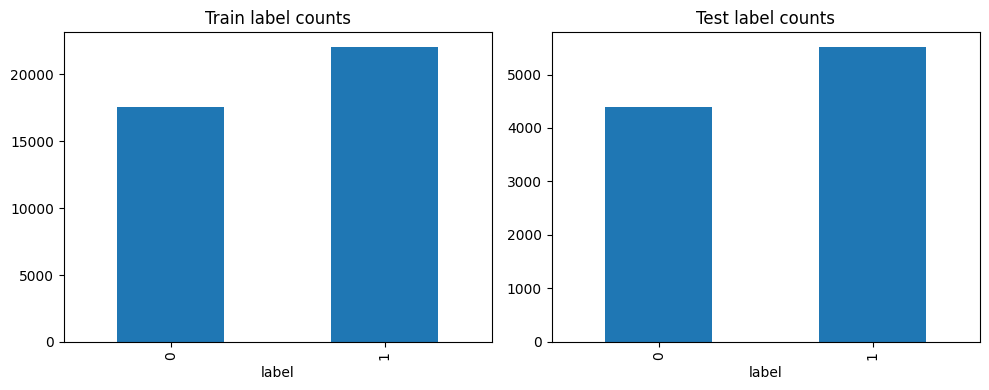

In [16]:
# 3.1 Class balance
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
train_df["label"].value_counts().sort_index().plot(kind="bar", ax=ax[0], title="Train label counts")
test_df["label"].value_counts().sort_index().plot(kind="bar", ax=ax[1], title="Test label counts")
plt.tight_layout()
plt.show()


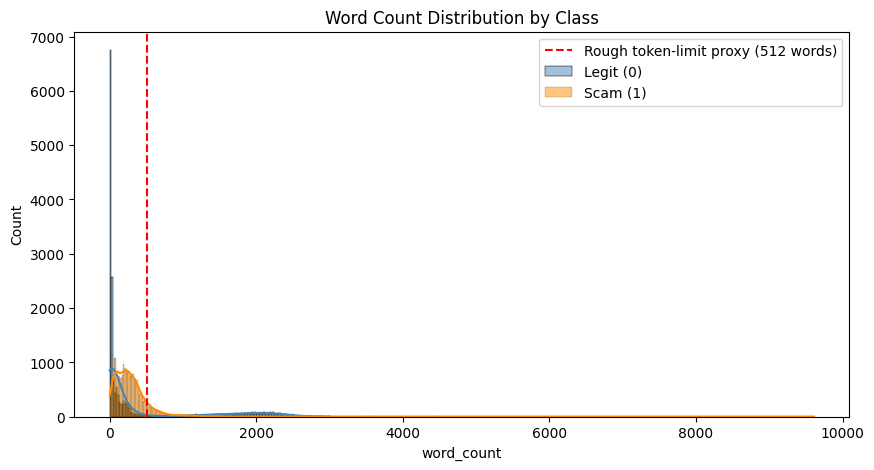

In [17]:
# 3.2 Word-count distribution by class
plt.figure(figsize=(10, 5))
sns.histplot(train_df[train_df["label"] == 0]["word_count"], color="steelblue", label="Legit (0)", kde=True, alpha=0.5)
sns.histplot(train_df[train_df["label"] == 1]["word_count"], color="darkorange", label="Scam (1)", kde=True, alpha=0.5)
plt.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"Rough token-limit proxy ({MAX_LENGTH} words)")
plt.title("Word Count Distribution by Class")
plt.xlabel("word_count")
plt.legend()
plt.show()


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (3112 > 512). Running this sequence through the model will result in indexing errors


Legit % over 512 tokens: 22.93823228301672
Scam % over 512 tokens: 21.316159463014195


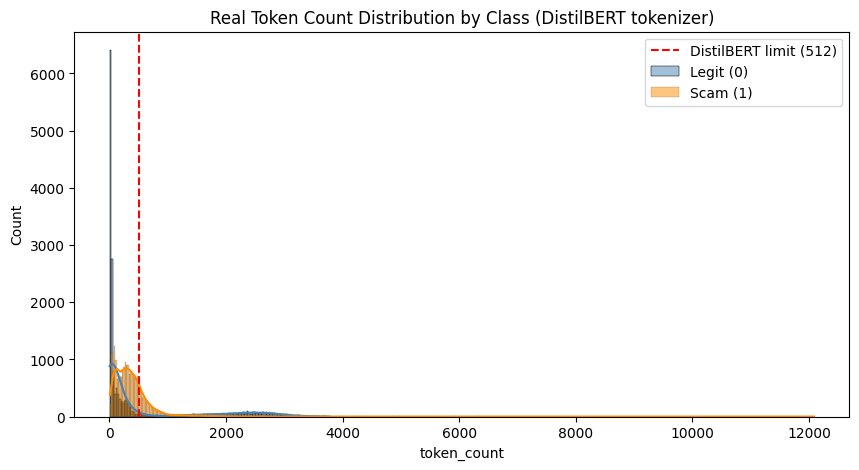

In [18]:
# 3.3 REAL token-count distribution using the actual DistilBERT tokenizer (not a word-count proxy)
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def token_len(text):
    return len(tokenizer.encode(str(text), truncation=False))

train_df["token_count"] = train_df["text"].apply(token_len)
test_df["token_count"] = test_df["text"].apply(token_len)

legit_tok = train_df[train_df["label"] == 0]["token_count"]
scam_tok = train_df[train_df["label"] == 1]["token_count"]

print(f"Legit % over {MAX_LENGTH} tokens:", (legit_tok > MAX_LENGTH).mean() * 100)
print(f"Scam % over {MAX_LENGTH} tokens:", (scam_tok > MAX_LENGTH).mean() * 100)

plt.figure(figsize=(10, 5))
sns.histplot(legit_tok, color="steelblue", label="Legit (0)", kde=True, alpha=0.5)
sns.histplot(scam_tok, color="darkorange", label="Scam (1)", kde=True, alpha=0.5)
plt.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"DistilBERT limit ({MAX_LENGTH})")
plt.title("Real Token Count Distribution by Class (DistilBERT tokenizer)")
plt.xlabel("token_count")
plt.legend()
plt.show()


In [19]:
# 3.4 Vocabulary signal — signed log-odds of top terms per class (more principled than raw bigram counts)
from collections import Counter
import math

def signed_log_odds(df, text_col="text", label_col="label", top_n=20, min_count=5):
    vec = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
    X = vec.fit_transform(df[text_col].astype(str))
    vocab = np.array(vec.get_feature_names_out())

    counts_pos = np.asarray(X[df[label_col].values == 1].sum(axis=0)).flatten()
    counts_neg = np.asarray(X[df[label_col].values == 0].sum(axis=0)).flatten()

    mask = (counts_pos + counts_neg) >= min_count
    vocab, counts_pos, counts_neg = vocab[mask], counts_pos[mask], counts_neg[mask]

    total_pos, total_neg = counts_pos.sum(), counts_neg.sum()
    log_odds = np.log((counts_pos + 1) / (total_pos - counts_pos + 1)) - \
               np.log((counts_neg + 1) / (total_neg - counts_neg + 1))

    order = np.argsort(log_odds)
    top_legit = vocab[order[:top_n]]
    top_scam = vocab[order[::-1][:top_n]]
    return top_scam, top_legit

top_scam_terms, top_legit_terms = signed_log_odds(train_df)
print("Top SCAM-indicative terms:", list(top_scam_terms))
print()
print("Top LEGIT-indicative terms:", list(top_legit_terms))


Top SCAM-indicative terms: ['zhang', 'xiao', 'li', 'provide id', 'xiao li', 'abnormal', 'bank card', 'service center', 'rupees', 'ming', 'xiao zhang', 'safety funds', 'need cooperate', 'thank cooperation', 'order ensure', 'security account', 'cooperate', 'mr zhang', 'hua', 'wei']

Top LEGIT-indicative terms: ['lor', 'da', 'lt', 'gt', 'lt gt', 'personality', 'movie', 'greetings', 'movies', 'calling xyz', 'hi calling', 'dementia', 'sarah', 'sorry dialed', 'liked', 'wrong number', 'coronavirus', 'dialed wrong', 'dog', 'dr smith']


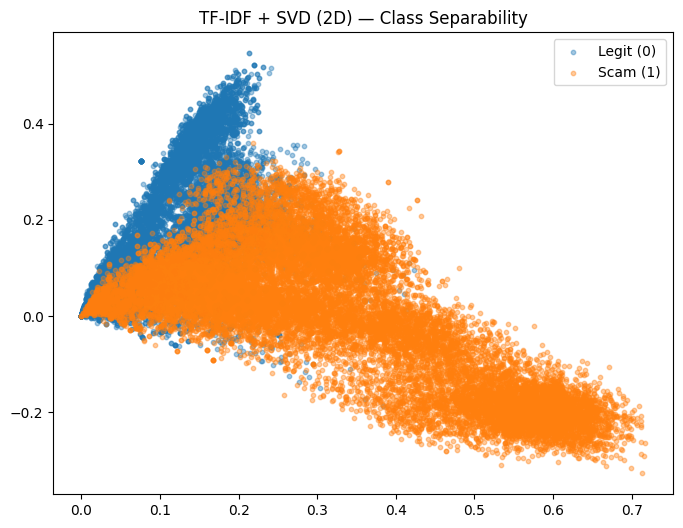

In [20]:
# 3.5 Class separability — TF-IDF + SVD 2D projection
vec2 = TfidfVectorizer(max_features=3000, stop_words="english")
X_tfidf = vec2.fit_transform(train_df["text"].astype(str))
svd = TruncatedSVD(n_components=2, random_state=SEED)
X_2d = svd.fit_transform(X_tfidf)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[train_df["label"] == 0, 0], X_2d[train_df["label"] == 0, 1], alpha=0.4, label="Legit (0)", s=10)
plt.scatter(X_2d[train_df["label"] == 1, 0], X_2d[train_df["label"] == 1, 1], alpha=0.4, label="Scam (1)", s=10)
plt.title("TF-IDF + SVD (2D) — Class Separability")
plt.legend()
plt.show()


**Manual read-through step (do this, don't skip):** pull 5-10 random rows per class and read them. Confirm scam examples show real social-engineering pretexts and legit examples read as genuinely benign — this is the cheap, high-value sanity check that catches label-quality issues no automated check will find.


In [21]:
pd.set_option("display.max_colwidth", 300)
print("=== Sample LEGIT rows ===")
display(train_df[train_df["label"] == 0].sample(5, random_state=1)[["text", "type"]] if "type" in train_df.columns else train_df[train_df["label"] == 0].sample(5, random_state=1)[["text"]])

print("\n=== Sample SCAM rows ===")
display(train_df[train_df["label"] == 1].sample(5, random_state=1)[["text", "type"]] if "type" in train_df.columns else train_df[train_df["label"] == 1].sample(5, random_state=1)[["text"]])


=== Sample LEGIT rows ===


,text,type
13682,Oh k...i'm watching here:),NaN
14064,"Do you have a complex regarding your appearance? I have no experience of being made to think that I have this kind of complex, or of being made fun of for having this kind of complex, and I think that the fact that I have a big nose is a complex about my appearance. I think I have a complex abou...",NaN
29213,"Hi, this is Karen from Dr. Smith's office. I'm calling to confirm your appointment for tomorrow at 2 PM. Ah, yeah! I think I have an appointment, but can you tell me a little bit more about what it's for? I'm trying to remember. Of course! You're scheduled for a follow-up on your recent blood wo...",NaN
37462,"Hello. Hey Sarah! How's it going? I was thinking about our plans for the weekend and I wanted to confirm if we're still on for brunch on Sunday? I'm sorry, I think you may have the wrong number. I'm not Sarah, and I don't have any plans with you for brunch on Sunday. I'm so sorry! I must have d...",NaN
8650,R U &SAM P IN EACHOTHER. IF WE MEET WE CAN GO 2 MY HOUSE,NaN



=== Sample SCAM rows ===


,text,type
38914,"'Your son is in our hands now. If you want him to come back safely, prepare five hundred thousand cash immediately. Do not call the police or you will bear the consequences. ', ""Who are you? Where is my son now? You can't do this, I'm going to call the police! """,NaN
36658,"""Hello, I'm Manager Zhang from Galaxy Investments, and we recently discovered a very promising investment project, which I think might be very attractive to you. "", 'Of course, this is an emerging green energy project with huge room for growth expected in the next few years. After our internal a...",NaN
24920,"'Welcome to the taxi service, please tell me your pick-up location and destination. ', 'The boarding location is at the entrance of the company, the destination is home, and the address is No. 10, East Third Ring North Road, Chaoyang District. ', 'Okay, your pick-up location is at the entrance o...",NaN
19893,"'Hello, I am the customer service representative of the bank where you opened your account. My name is Li Hua. We found that there are abnormal transactions in your account and require your cooperation for security verification. Is it convenient for you now? ', ""Hello, Li Hua. I really haven't u...",NaN
6605,"Innocent: Hello. Suspect: Hello, this is John from TechCare Solutions. We've been monitoring your computer's activity and detected a severe virus infection. It's a very serious issue that needs immediate attention to prevent data loss and identity theft. Can you please confirm your computer's o...",support


## 4. Baseline Models (Classical ML)

In [22]:
tfidf = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df["text"].astype(str))
X_test_tfidf = tfidf.transform(test_df["text"].astype(str))

y_train = train_df["label"].values
y_test = test_df["label"].values


In [23]:
# 4.1 Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
logreg.fit(X_train_tfidf, y_train)
preds_lr = logreg.predict(X_test_tfidf)

print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, preds_lr))
print(classification_report(y_test, preds_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds_lr))


--- Logistic Regression ---
Accuracy: 0.9866774323778764
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4395
           1       0.99      0.98      0.99      5513

    accuracy                           0.99      9908
   macro avg       0.99      0.99      0.99      9908
weighted avg       0.99      0.99      0.99      9908

Confusion Matrix:
 [[4346   49]
 [  83 5430]]


In [24]:
# 4.2 LightGBM
lgb_train = lgb.Dataset(X_train_tfidf, label=y_train)
lgb_params = {"objective": "binary", "metric": "binary_logloss", "verbosity": -1, "seed": SEED}
lgb_model = lgb.train(lgb_params, lgb_train, num_boost_round=200)

pred_proba_lgb = lgb_model.predict(X_test_tfidf)
preds_lgb = (pred_proba_lgb > 0.5).astype(int)

print("--- LightGBM ---")
print("Accuracy:", accuracy_score(y_test, preds_lgb))
print(classification_report(y_test, preds_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds_lgb))


--- LightGBM ---
Accuracy: 0.9953572870407751
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4395
           1       1.00      1.00      1.00      5513

    accuracy                           1.00      9908
   macro avg       1.00      1.00      1.00      9908
weighted avg       1.00      1.00      1.00      9908

Confusion Matrix:
 [[4375   20]
 [  26 5487]]


**Critical check before moving to DistilBERT:** if either baseline above already scores ~98-100%, that means this dataset is too easily separable to meaningfully differentiate model architectures — the honest conclusion would be "this dataset isn't adversarial/subtle enough," not "DistilBERT underperforms." Read this result before investing GPU time in fine-tuning.


## 5. DistilBERT Fine-Tuning

In [25]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

set_seed(SEED)

train_ds = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True))

# *** Uses the SAME MAX_LENGTH defined in cell 0 — this is the fix for the earlier 256-vs-512 mismatch ***
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/39631 [00:00<?, ? examples/s]

Map:   0%|          | 0/9908 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    exp_logits = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)
    pos_probs = probs[:, 1]
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    pr_auc = average_precision_score(labels, pos_probs)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "pr_auc": pr_auc}

training_args = TrainingArguments(
    output_dir="/kaggle/working/scam-classifier-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=20,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.024724,0.022135,0.996871,0.997098,0.997279,0.997189,0.999961
2,0.005794,0.035834,0.996568,0.995299,0.998549,0.996921,0.999956
3,0.023337,0.027562,0.997477,0.996562,0.998912,0.997735,0.999960
4,0.001133,0.023967,0.997780,0.997103,0.998912,0.998007,0.999975


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4956, training_loss=0.026377094419505087, metrics={'train_runtime': 4870.0857, 'train_samples_per_second': 32.551, 'train_steps_per_second': 1.018, 'total_flos': 2.099892245683469e+16, 'train_loss': 0.026377094419505087, 'epoch': 4.0})

In [27]:
metrics = trainer.evaluate()
print("Final evaluation metrics on test set:", metrics)

predictions = trainer.predict(test_ds)
preds = np.argmax(predictions.predictions, axis=-1)
y_true = np.array(test_ds["label"])

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, preds))


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final evaluation metrics on test set: {'eval_loss': 0.02396714687347412, 'eval_accuracy': 0.9977795720629794, 'eval_precision': 0.9971030237189933, 'eval_recall': 0.9989116633411935, 'eval_f1': 0.9980065241029359, 'eval_pr_auc': 0.9999747730624517, 'eval_runtime': 97.2602, 'eval_samples_per_second': 101.871, 'eval_steps_per_second': 3.187, 'epoch': 4.0}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Confusion Matrix:
[[4379   16]
 [   6 5507]]


### Stratified length-based evaluation — now correctly aligned

This uses the **same `MAX_LENGTH`** that was actually used to truncate inputs during training/tokenization. This is the fix for the earlier bug (training used 256, the check used 512 — meaning both "short" and "long" groups had already been truncated identically, making the comparison meaningless).


In [28]:
long_mask = (test_df["token_count"] > MAX_LENGTH).values
short_mask = ~long_mask

print(f"N short (<= {MAX_LENGTH} tokens):", short_mask.sum())
print(f"N long  (> {MAX_LENGTH} tokens):", long_mask.sum())

if short_mask.sum() > 0:
    acc_short = accuracy_score(y_true[short_mask], preds[short_mask])
    print(f"DistilBERT accuracy, short transcripts (<= {MAX_LENGTH} tokens): {acc_short:.2%}")

if long_mask.sum() > 0:
    acc_long = accuracy_score(y_true[long_mask], preds[long_mask])
    print(f"DistilBERT accuracy, long transcripts (> {MAX_LENGTH} tokens): {acc_long:.2%}")


N short (<= 512 tokens): 7723
N long  (> 512 tokens): 2185
DistilBERT accuracy, short transcripts (<= 512 tokens): 99.72%
DistilBERT accuracy, long transcripts (> 512 tokens): 100.00%


**How to read this result:**
- If accuracy is clearly **lower** on the long-transcript subset → real, specific evidence that truncation causes information loss — a legitimate, precise architectural argument for your report.
- If accuracy is **similar** across both subsets → truncation isn't the driver of any DistilBERT weakness; look elsewhere (front-loaded signal, dataset simplicity — check the baseline results in Section 4 to see if classical ML also scores near-ceiling, which would point to dataset simplicity rather than a DistilBERT-specific issue).
- If **DistilBERT's overall accuracy is already ~98-100%** (same as the classical baselines in Section 4) → the honest conclusion is that this dataset doesn't yet differentiate model architectures. That's a valid, reportable finding — but it means you need a harder/more subtle dataset before claiming Qwen adds value, not that Qwen should be assumed to win.


## 6. Summary Table (fill in after running all cells above)

| Model | Accuracy | F1 | Notes |
|---|---|---|---|
| Word-count only (Section 2.4) | | | shortcut-detection sanity check |
| TF-IDF + Logistic Regression | | | |
| TF-IDF + LightGBM | | | |
| DistilBERT (max_length={MAX_LENGTH}) | | | |
| — short transcripts only | | | |
| — long transcripts only | | | |

## 7. Next Steps (separate notebook)

If the results above show a genuine gap (baselines noticeably below DistilBERT, or clear signs the dataset has enough difficulty to differentiate models) — proceed to a follow-up notebook: **Qwen2.5-1.5B-Instruct LoRA fine-tuning** with a classification + fraud-category + reasoning output format, evaluated with the same stratified length breakdown, so any advantage can be checked against the same "does it come from handling long context" hypothesis tested here.

If the results above show near-ceiling accuracy across every model (classical and DistilBERT alike) — the honest next step is sourcing or generating a harder, more subtle/adversarial dataset before fine-tuning Qwen, since there would be no signal left for a bigger model to meaningfully improve on.
